# DSA 210 Project Progress: Data Collection, EDA, and Hypothesis Testing

## Project Topic
This project investigates impulsive purchasing behavior in online shopping environments. It focuses on how the timing of purchases may influence whether a decision is more impulsive or rational.

## Dataset
The dataset used in this project is the Online Retail dataset obtained from Kaggle. It contains transaction-level data including timestamps, product information, quantities, and customer behavior. The dataset consists of several hundred thousand transactions, allowing analysis of purchasing patterns over time.

Dataset source: https://www.kaggle.com/datasets/vijayuv/onlineretail

## Current Work
In this notebook, I:
- loaded and cleaned the dataset,
- created time-based features such as hour and day,
- performed exploratory data analysis (EDA) to understand purchase patterns,
- - visualized purchase distribution across hours, days, quantities, and countries,
- created multiple visualizations for hour, day, quantity, and country-based purchase patterns,
- conducted multiple hypothesis tests to compare purchasing behavior across different time periods.

## Hypothesis
H0 (Null Hypothesis): There is no significant difference in purchasing behavior between daytime and evening purchases.

H1 (Alternative Hypothesis): There is a significant difference in purchasing behavior between daytime and evening purchases.

## Initial Findings

The exploratory analysis shows that purchases are concentrated in certain hours and vary across days of the week. Most transactions involve small quantities, while a few transactions include much larger quantities. The country-based analysis also shows that the dataset is geographically concentrated, especially around the United Kingdom. Additional hypothesis tests are used to compare purchasing behavior across different time periods.

### Dataset Upload

The dataset file is uploaded directly into the Colab environment before analysis.

In [27]:
from google.colab import files
uploaded = files.upload()

Saving OnlineRetail.csv to OnlineRetail.csv


In [28]:
import pandas as pd
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1", on_bad_lines="skip")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [29]:
## Data Cleaning
df = df.dropna()
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df.shape

(397884, 8)

In [30]:
## Feature Engineering
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['hour'] = df['InvoiceDate'].dt.hour
df['day'] = df['InvoiceDate'].dt.day_name()

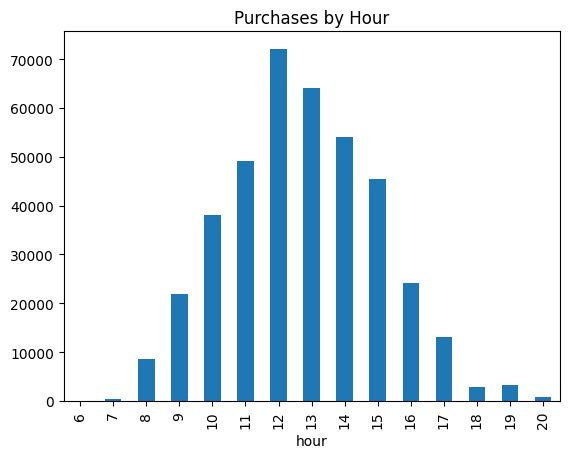

In [31]:
## Exploratory Data Analysis
import matplotlib.pyplot as plt
df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Purchases by Hour")
plt.show()

Purchases are concentrated in certain hours, suggesting possible impulsive buying patterns.

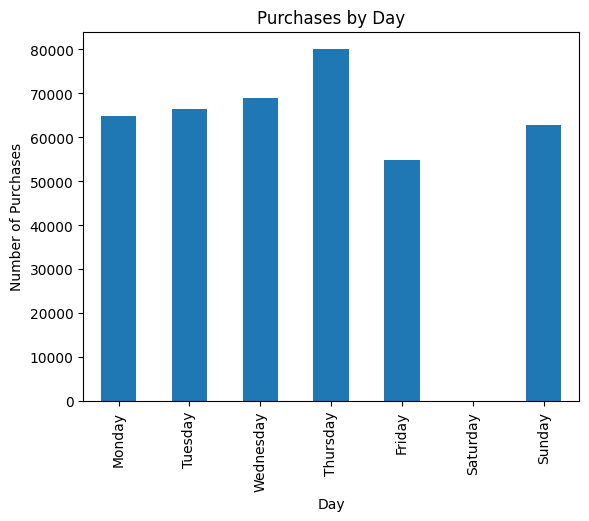

In [32]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day'].value_counts().reindex(day_order).plot(kind='bar')
plt.title("Purchases by Day")
plt.xlabel("Day")
plt.ylabel("Number of Purchases")
plt.show()

Purchases differ across days of the week. This may indicate that customer shopping behavior changes depending on weekly routines and activity levels.There are no recorded purchases on Saturday in this dataset.

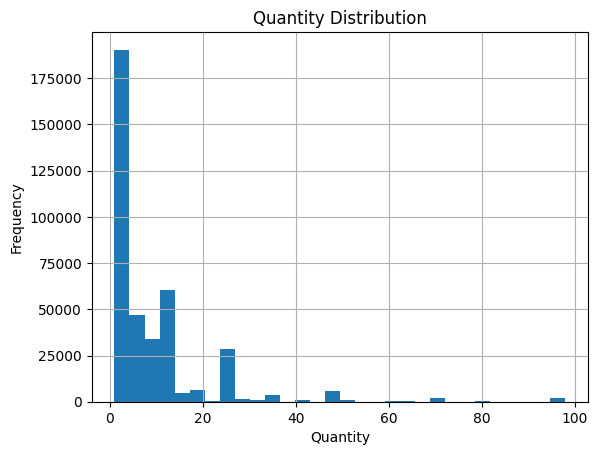

In [33]:
df[df['Quantity'] < 100]['Quantity'].hist(bins=30)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

Most transactions contain relatively small quantities, while only a limited number of purchases involve large quantities.

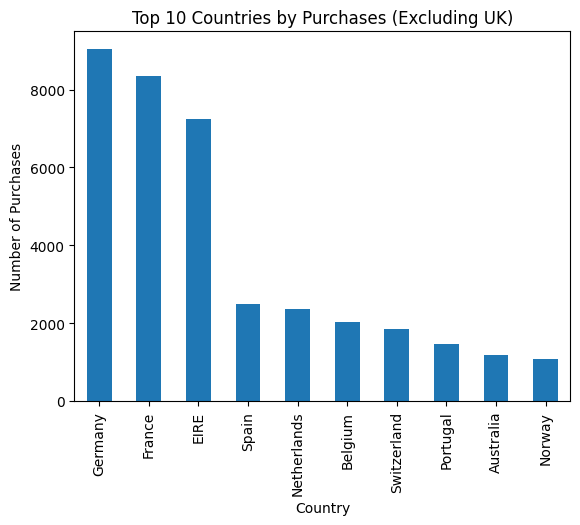

In [34]:
country_counts = df[df['Country'] != 'United Kingdom']['Country'].value_counts().head(10)
country_counts.plot(kind='bar')
plt.title("Top 10 Countries by Purchases (Excluding UK)")
plt.xlabel("Country")
plt.ylabel("Number of Purchases")
plt.show()

The majority of purchases originate from a small number of countries, suggesting that transaction activity is concentrated geographically.After excluding the United Kingdom, transaction activity from other countries becomes more visible. This suggests that purchasing behavior is still geographically concentrated, but several European countries also contribute noticeably to the dataset.

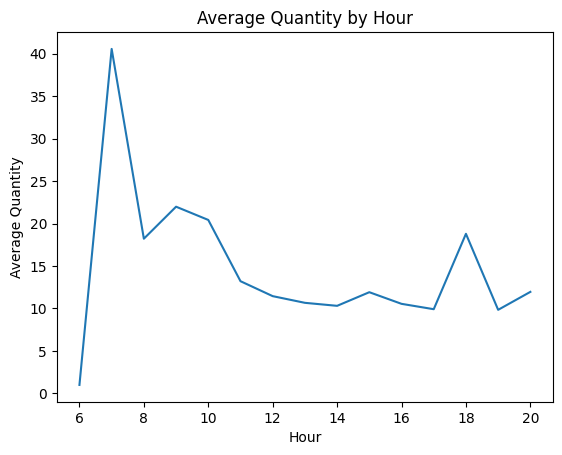

In [35]:
df.groupby('hour')['Quantity'].mean().plot()
plt.title("Average Quantity by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Quantity")
plt.show()

Average purchase quantity varies across hours, suggesting that purchasing intensity may differ depending on the time of day.

In [36]:
## Hypothesis Testing
from scipy.stats import ttest_ind
night = df[df['hour'] >= 18]['Quantity']
day = df[df['hour'] < 18]['Quantity']
ttest_ind(night, day)

TtestResult(statistic=np.float64(0.38185043550585357), pvalue=np.float64(0.7025725100448659), df=np.float64(397882.0))

This test compares evening and daytime purchases. If a significant difference is observed, it may indicate differences in purchasing behavior related to time.The p-value is relatively high, suggesting that there is no strong statistical evidence of a difference between evening and daytime purchases.

In [37]:
df['is_weekend'] = df['InvoiceDate'].dt.weekday >= 5
weekday = df[df['is_weekend'] == False]['Quantity']
weekend = df[df['is_weekend'] == True]['Quantity']
ttest_ind(weekday, weekend)

TtestResult(statistic=np.float64(8.460642041983117), pvalue=np.float64(2.6679068446648538e-17), df=np.float64(397882.0))

This hypothesis test compares weekday and weekend purchasing quantities to determine whether shopping behavior changes across different parts of the week. The p-value is lower than 0.05, indicating a statistically significant difference between weekday and weekend purchase quantities.

In [38]:
morning = df[df['hour'] < 12]['Quantity']
evening = df[df['hour'] >= 18]['Quantity']
ttest_ind(morning, evening)

TtestResult(statistic=np.float64(0.989662338297473), pvalue=np.float64(0.3223411025755717), df=np.float64(125144.0))

This test examines whether purchase quantity differs between morning and evening shopping periods.The hypothesis test does not provide strong statistical evidence of a difference between morning and evening purchasing behavior.

# Machine Learning Methods

In this section, I apply machine learning methods to classify purchases as impulsive or non-impulsive using the features created from the online retail dataset.

In [39]:
# Create an impulsive purchase proxy
# A purchase is labeled as impulsive if it happens in the evening and has quantity greater than 5.
df['impulsive'] = ((df['hour'] >= 18) & (df['Quantity'] > 5)).astype(int)
df[['hour', 'Quantity', 'UnitPrice', 'impulsive']].head()

,hour,Quantity,UnitPrice,impulsive
0,8,6,2.55,0
1,8,6,3.39,0
2,8,8,2.75,0
3,8,6,3.39,0
4,8,6,3.39,0


## Feature Selection

I use hour, quantity, and unit price as input features to predict whether a purchase can be classified as impulsive.

In [40]:
X = df[['hour', 'Quantity', 'UnitPrice']]
y = df['impulsive']
X.head()

,hour,Quantity,UnitPrice
0,8,6,2.55
1,8,6,3.39
2,8,8,2.75
3,8,6,3.39
4,8,6,3.39


## Train-Test Split

The data is divided into training and testing sets so that the model can be evaluated on unseen data.

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression Model

In [42]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Model Evaluation

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9922590698317353

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     79017
           1       0.38      0.15      0.22       560

    accuracy                           0.99     79577
   macro avg       0.69      0.58      0.61     79577
weighted avg       0.99      0.99      0.99     79577


Confusion Matrix:
[[78875   142]
 [  474    86]]


The logistic regression model was used to classify purchases as impulsive or non-impulsive based on hour, quantity, and unit price. Since impulsiveness is not directly provided in the dataset, it was approximated using a rule-based proxy. The model results give an initial idea of whether transaction-level features can help predict impulsive purchasing behavior. The machine learning results suggest that time-related features may provide useful information for identifying purchasing behavior patterns. However, since impulsiveness is approximated using a rule-based proxy instead of direct behavioral labels, the model results should be interpreted cautiously.

Although the model achieved a high accuracy score, the dataset is highly imbalanced because impulsive purchases represent only a small portion of the observations. Therefore, accuracy alone may not fully reflect model performance. The relatively low recall for impulsive purchases indicates that the model has difficulty identifying all impulsive transactions correctly.

In [44]:
!git clone https://github.com/cahidekaya/Dsa210-Project.git

Cloning into 'Dsa210-Project'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 57 (delta 29), reused 25 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 221.31 KiB | 5.82 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [45]:
%cd Dsa210-Project

/content/Dsa210-Project/Dsa210-Project


In [46]:
!git tag milestone1
!git push origin milestone1

fatal: tag 'milestone1' already exists
fatal: could not read Username for 'https://github.com': No such device or address


## Hyperparameter Tuning with GridSearchCV

In this section, I use GridSearchCV to tune hyperparameters for Logistic Regression, Decision Tree, and Random Forest models. The models are compared using accuracy, precision, recall, and F1 score.

In [47]:
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "C": [0.01, 0.1, 1, 10]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [3, 5, 10, None],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [5, 10, None]
        }
    }
}

results = []

for name, item in models.items():
    grid = GridSearchCV(
        item["model"],
        item["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    results.append({
        "Model": name,
        "Best Parameters": grid.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Best Parameters,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,{'C': 1},0.992259,0.377193,0.153571,0.218274
1,Decision Tree,"{'max_depth': 3, 'min_samples_split': 2}",1.000000,1.000000,1.000000,1.000000
2,Random Forest,"{'max_depth': 5, 'n_estimators': 50}",1.000000,1.000000,1.000000,1.000000


## Model Performance Visualization

The following plot compares the tuned models using accuracy, precision, recall, and F1 score.

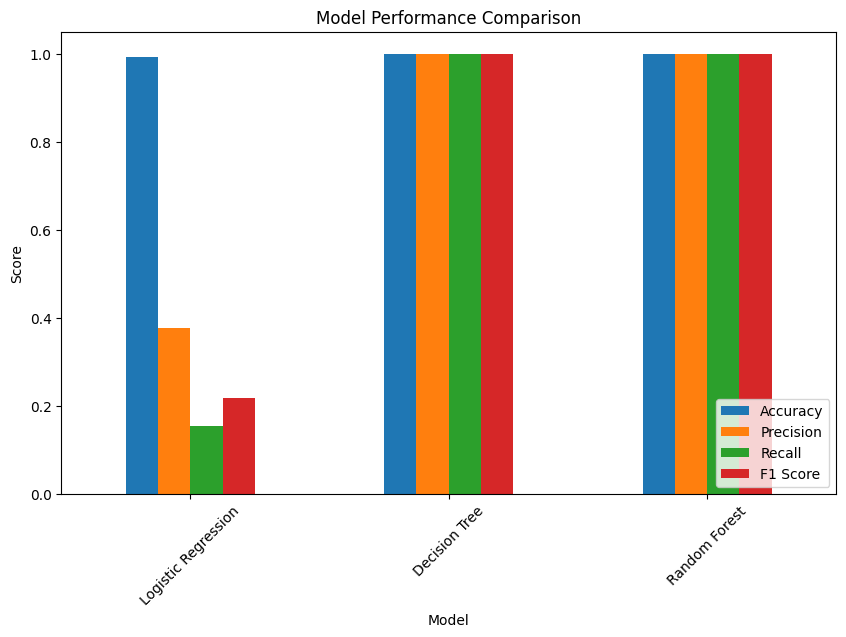

In [48]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.show()

The visualization shows that different models perform differently across evaluation metrics. While some models achieve high accuracy, F1 score and recall provide better insight for identifying impulsive purchasing behavior due to class imbalance.

## Training and Test Performance Comparison

This section compares training and test F1 scores to evaluate whether the models generalize well or overfit the training data.

In [49]:
train_test_results = []
for name, item in models.items():
    grid = GridSearchCV(
        item["model"],
        item["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    train_pred = best_model.predict(X_train)
    test_pred = best_model.predict(X_test)

    train_test_results.append({
        "Model": name,
        "Train F1 Score": f1_score(y_train, train_pred, zero_division=0),
        "Test F1 Score": f1_score(y_test, test_pred, zero_division=0)
    })

train_test_df = pd.DataFrame(train_test_results)
train_test_df

,Model,Train F1 Score,Test F1 Score
0,Logistic Regression,0.218677,0.218274
1,Decision Tree,1.000000,1.000000
2,Random Forest,1.000000,1.000000


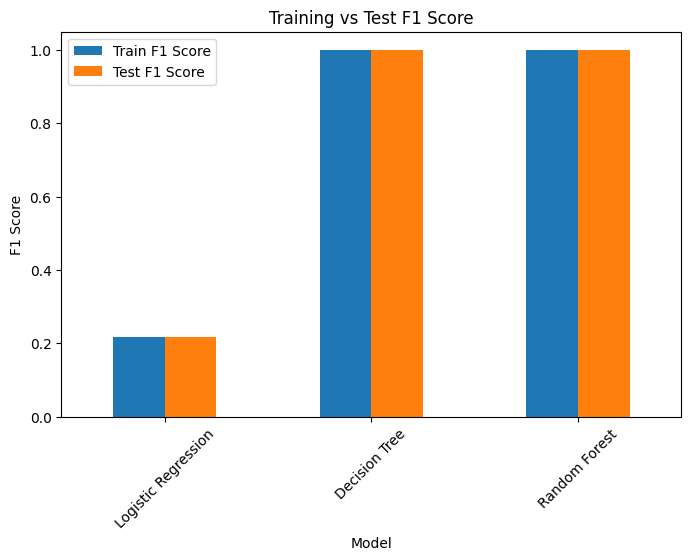

In [50]:
train_test_df.set_index("Model").plot(kind="bar", figsize=(8, 5))
plt.title("Training vs Test F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()

## Validation Performance from GridSearchCV

GridSearchCV uses cross-validation on the training data. The best validation F1 score shows how well each model performs during hyperparameter tuning.

In [25]:
validation_results = []
for name, item in models.items():
    grid = GridSearchCV(
        item["model"],
        item["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    validation_results.append({
        "Model": name,
        "Best Validation F1 Score": grid.best_score_
    })

validation_df = pd.DataFrame(validation_results)
validation_df

,Model,Best Validation F1 Score
0,Logistic Regression,0.217517
1,Decision Tree,1.000000
2,Random Forest,1.000000


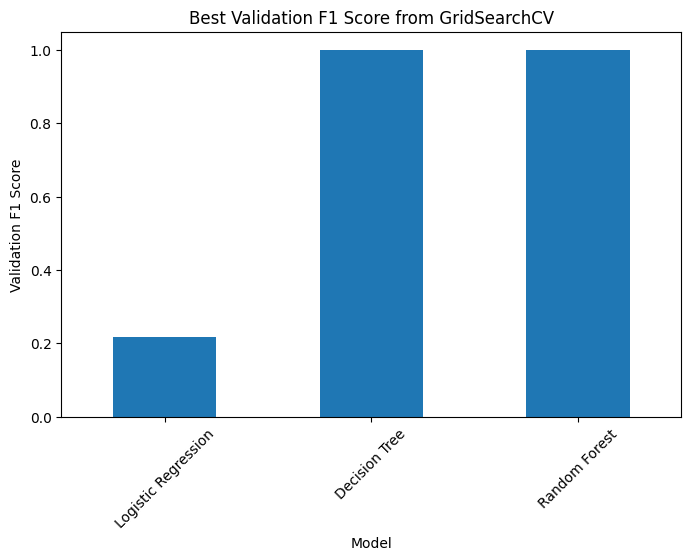

In [26]:
validation_df.set_index("Model").plot(kind="bar", figsize=(8, 5), legend=False)
plt.title("Best Validation F1 Score from GridSearchCV")
plt.xlabel("Model")
plt.ylabel("Validation F1 Score")
plt.xticks(rotation=45)
plt.show()

## ML Interpretation

The machine learning part compares Logistic Regression, Decision Tree, and Random Forest models. GridSearchCV is used to tune selected hyperparameters for each model, and the models are evaluated using accuracy, precision, recall, and F1 score.

Since the impulsive purchase label is created as a rule-based proxy rather than a directly observed behavioral label, the results should be interpreted carefully. Accuracy alone is not sufficient because the dataset is imbalanced, with impulsive purchases representing a smaller portion of the observations. Therefore, precision, recall, and F1 score are also considered.

The comparison of training, validation, and test performance helps evaluate whether the models generalize well or overfit the training data. Models with higher validation and test F1 scores are more useful for identifying impulsive purchasing patterns.

## Conclusion

This project explored impulsive purchasing behavior using the Online Retail dataset. Through exploratory data analysis, hypothesis testing, and machine learning methods, several patterns related to purchasing time and quantity were identified. While the dataset does not directly measure impulsiveness, the project demonstrates how transaction-level features can be used to analyze customer purchasing behavior. Future work may include using additional behavioral features and more advanced machine learning models to better capture impulsive purchasing behavior.